# Introduction

Clustering analysis is a technique used to group similar data points together based on their characteristics. In financial markets, clustering analysis can be used to identify patterns and relationships in large datasets with many variables. Here are the steps to use clustering analysis in financial markets:

1. Define the problem: The first step is to define the problem you want to solve. For example, you may want to cluster companies based on their financial performance or to cluster investors based on their investment strategies.
2. Collect the data: Collect the relevant data, such as financial statements, news articles, or market data.
3. Preprocess the data: The data may need to be cleaned, transformed, and normalized before it can be used for clustering.
4. Select the clustering algorithm: There are many clustering algorithms to choose from, such as k-means, hierarchical clustering, and density-based clustering. The choice of algorithm depends on the nature of the data and the problem you are trying to solve.
5. Set the parameters: Depending on the clustering algorithm, you may need to set parameters such as the number of clusters, the linkage criterion, or the threshold density.
6. Cluster the data: The clustering algorithm is applied to the data, and the data points are grouped into clusters based on their characteristics.
7. Evaluate the results: The results of the clustering analysis can be evaluated using metrics such as the silhouette score, the elbow method, or the dendrogram.
8. Interpret the results: The clusters can be interpreted in the context of the problem you defined in step 1. For example, you may want to investigate the financial performance of the companies in each cluster or the investment strategies of the investors in each cluster.

It's important to note that clustering analysis is a powerful technique, but it's also important to understand the limitations and assumptions of the technique before applying it to financial markets. Additionally, it's important to validate the results of the clustering analysis with other techniques and domain knowledge.

-  Clustering is extensively used in the machine learning
-  Clustering is also used in finance
    -  to predict equity prices and trading volume
    -  to construct psedo mean-variance frontier
    -  In JPM, they used for "what are the most common signs of market stress?"

- partition observation into k-cluster sets
- more formally
 - partitioning $m$ observations $(x_1, x_2, \cdots, x_m)$, where $x_i$ is $p$-dimentional real vector, into $k \le m$ cluster sets $(c_1, c_2, \cdots, c_k)$ with means
 $({\bar{m_1}, \bar{m_2}, \cdots, \bar{m_k}})$ such that
 \begin{equation*}
     argmin \sum_{i=1}^{k}\sum_{x \in c_i}||x-\bar{m_i} ||^2
 \end{equation*}


# Usual Procedure in a flow chart

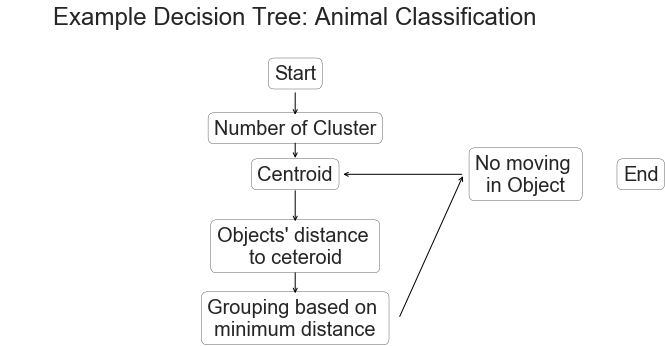

In [ ]:
fig = plt.figure(figsize=(10, 4))
ax = fig.add_axes([0, 0, 0.8, 1], frameon=False, xticks=[], yticks=[])
ax.set_title('Example Decision Tree: Animal Classification', size=24)

def text(ax, x, y, t, size=20, **kwargs):
    ax.text(x, y, t,
            ha='center', va='center', size=size,
            bbox=dict(boxstyle='round', ec='k', fc='w'), **kwargs)

text(ax, 0.5, 0.85, "Start", 20);
text(ax, 0.5, 0.66, "Number of Cluster", 20);
text(ax, 0.5, 0.5, "Centroid", 20);
text(ax, 0.5, 0.25, "Objects' distance \nto ceteroid", 20);
text(ax, 0.5, 0.0, "Grouping based on \nminimum distance", 20);
text(ax, 0.9, 0.5, "No moving \nin Object", 20);
text(ax, 1.1, 0.5, "End", 20);

ax.annotate('', [0.5, 0.7], [0.5, 0.79],
                     arrowprops=dict(arrowstyle='->', linewidth=1))
ax.annotate('', [0.5, 0.55], [0.5, 0.615],
                     arrowprops=dict(arrowstyle='->', linewidth=1))
ax.annotate('', [0.5, 0.33], [0.5, 0.45],
                     arrowprops=dict(arrowstyle='->', linewidth=1))
ax.annotate('', [0.5, 0.08], [0.5, 0.165],
                     arrowprops=dict(arrowstyle='->', linewidth=1))
ax.annotate('',  [0.58, 0.5],[0.7925, 0.5],
                     arrowprops=dict(arrowstyle='->', linewidth=1))
ax.annotate('',  [0.7925, 0.5], [0.68, 0],
                     arrowprops=dict(arrowstyle='->', linewidth=1)) ;

## EM Algorithm
-  E-Step: assign points to the nearest cluster center
-  M-Step: set the cluster centers to the mean

# KMeans clustering with artificial data

## usual empirical setup

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()

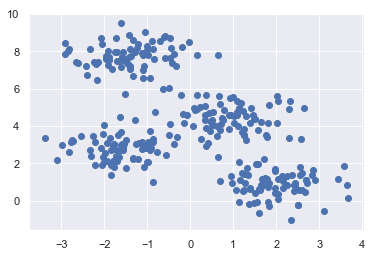

In [ ]:
from sklearn.datasets.samples_generator import make_blobs

X, y_true = make_blobs(300, centers=4, cluster_std=0.7, random_state=0 )

plt.scatter(X[:,0], X[:, 1])

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans()
kmeans.fit(X)
y_predict = kmeans.predict(X)

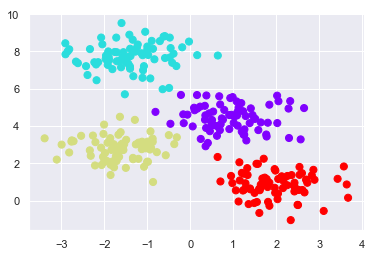

In [ ]:
plt.scatter(X[:,0], X[:,1], c=y_predict, s=50, cmap='rainbow')

## visualization of KMeans-clustering: Initialization

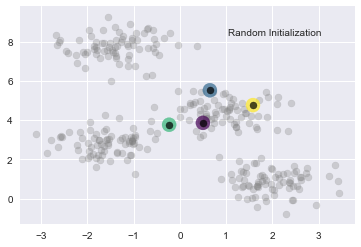

In [ ]:
from sklearn.datasets.samples_generator import make_blobs
from sklearn.metrics import pairwise_distances_argmin

X, y_true = make_blobs(n_samples=300, centers=4,
                       cluster_std=0.60, random_state=0)

rng = np.random.RandomState(42)
centers = [0, 4] + rng.randn(4, 2)

factor = 1
alpha = 0.7

plt.scatter(X[:, 0], X[:, 1], c='grey', cmap='viridis',
               s=50 * factor, alpha=0.3)

plt.scatter(centers[:, 0], centers[:, 1],
               c=np.arange(4), cmap='viridis', s=200 * factor,
               alpha=alpha)
plt.scatter(centers[:, 0], centers[:, 1],
               c='black', s=50 * factor, alpha=alpha)
#plt.text(3.5, 9, "Random Initialization", ha='right', va='top', size=16)
plt.text(0.9, 0.9, "Random Initialization", transform=plt.gca().transAxes, ha='right', va='top');

## visualization of KMeans-clustering: EM

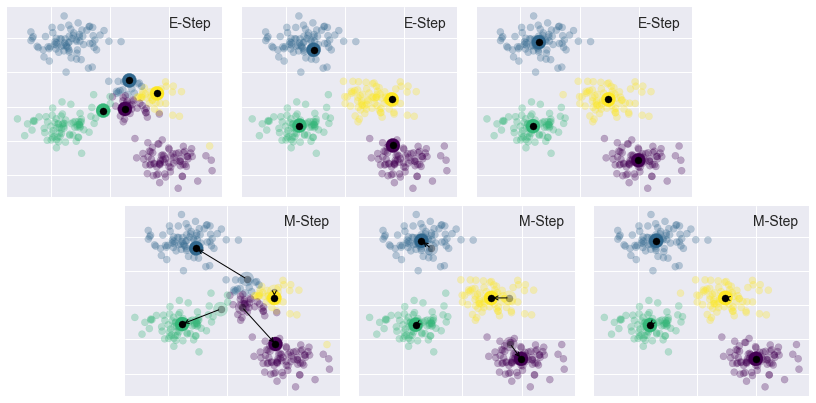

In [ ]:
from sklearn.datasets.samples_generator import make_blobs
from sklearn.metrics import pairwise_distances_argmin

X, y_true = make_blobs(n_samples=300, centers=4,
                       cluster_std=0.60, random_state=0)

rng = np.random.RandomState(42)
centers = [0, 4] + rng.randn(4, 2)

fig = plt.figure(figsize=(15, 6))
gs = plt.GridSpec(8, 9, left=0.02, right=0.98, bottom=0.05, top=0.95, wspace=0.2, hspace=0.2)

for i in range(3):
    ax1 = make_ax(fig, gs[:4,  2 * i:2 + 2 * i])
    ax2 = make_ax(fig, gs[4:, 1 + 2 * i:3 + 2 * i])

    # E-step
    y_pred = pairwise_distances_argmin(X, centers)
    draw_points(ax1, y_pred)
    draw_centers(ax1, centers)

    # M-step
    new_centers = np.array([X[y_pred == i].mean(0) for i in range(4)])
    draw_points(ax2, y_pred)
    draw_centers(ax2, centers, alpha=0.3)
    draw_centers(ax2, new_centers)
    for i in range(4):
        #print(centers[i], new_centers[i])
        #print('*************')
        ax2.annotate('', new_centers[i], centers[i],
                     arrowprops=dict(arrowstyle='->', linewidth=1))

    # Finish iteration
    centers = new_centers
    ax1.text(0.95, 0.95, "E-Step", transform=ax1.transAxes, ha='right', va='top', size=14)
    ax2.text(0.95, 0.95, "M-Step", transform=ax2.transAxes, ha='right', va='top', size=14)

In [ ]:
?pairwise_distances_argmin

## visualization of KMeans-clustering: In Sum

Text(0.98,0.98,'Final Clustering')

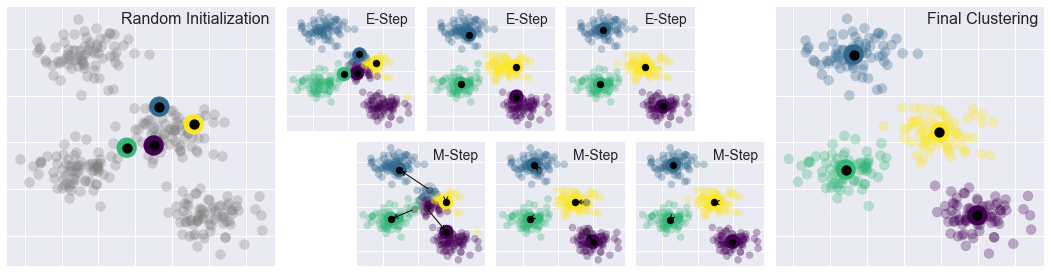

In [ ]:
from sklearn.datasets.samples_generator import make_blobs
from sklearn.metrics import pairwise_distances_argmin

X, y_true = make_blobs(n_samples=300, centers=4,
                       cluster_std=0.60, random_state=0)

rng = np.random.RandomState(42)
centers = [0, 4] + rng.randn(4, 2)

fig = plt.figure(figsize=(15, 4))
gs = plt.GridSpec(4, 15, left=0.02, right=0.98, bottom=0.05, top=0.95, wspace=0.2, hspace=0.2)
ax0 = make_ax(fig, gs[:4, :4])
ax0.text(0.98, 0.98, "Random Initialization", transform=ax0.transAxes,
         ha='right', va='top', size=16)
draw_points(ax0, 'gray', factor=2)
draw_centers(ax0, centers, factor=2)

for i in range(3):
    ax1 = make_ax(fig, gs[:2, 4 + 2 * i:6 + 2 * i])
    ax2 = make_ax(fig, gs[2:, 5 + 2 * i:7 + 2 * i])

    # E-step
    y_pred = pairwise_distances_argmin(X, centers)
    draw_points(ax1, y_pred)
    draw_centers(ax1, centers)

    # M-step
    new_centers = np.array([X[y_pred == i].mean(0) for i in range(4)])
    draw_points(ax2, y_pred)
    draw_centers(ax2, centers, alpha=0.3)
    draw_centers(ax2, new_centers)
    for i in range(4):
        ax2.annotate('', new_centers[i], centers[i],
                     arrowprops=dict(arrowstyle='->', linewidth=1))


    # Finish iteration
    centers = new_centers
    ax1.text(0.95, 0.95, "E-Step", transform=ax1.transAxes, ha='right', va='top', size=14)
    ax2.text(0.95, 0.95, "M-Step", transform=ax2.transAxes, ha='right', va='top', size=14)


# Final E-step
y_pred = pairwise_distances_argmin(X, centers)
axf = make_ax(fig, gs[:4, -4:])
draw_points(axf, y_pred, factor=2)
draw_centers(axf, centers, factor=2)
axf.text(0.98, 0.98, "Final Clustering", transform=axf.transAxes,
         ha='right', va='top', size=16)



In [ ]:
def draw_points(ax, c, factor=1):
    ax.scatter(X[:, 0], X[:, 1], c=c, cmap='viridis',
               s=50 * factor, alpha=0.3)

def draw_centers(ax, centers, factor=1, alpha=1.0):
    ax.scatter(centers[:, 0], centers[:, 1],
               c=np.arange(4), cmap='viridis', s=200 * factor,
               alpha=alpha)
    ax.scatter(centers[:, 0], centers[:, 1],
               c='black', s=50 * factor, alpha=alpha)

def make_ax(fig, gs):
    ax = fig.add_subplot(gs)
    ax.xaxis.set_major_formatter(plt.NullFormatter())
    ax.yaxis.set_major_formatter(plt.NullFormatter())
    return ax

from sklearn.metrics import pairwise_distances_argmin

def find_clusters(X, n_clusters, rseed=2):
    # 1. Randomly choose clusters
    rng = np.random.RandomState(rseed)
    i = rng.permutation(X.shape[0])[:n_clusters]
    centers = X[i]

    while True:
        # 2a. Assign labels based on closest center
        labels = pairwise_distances_argmin(X, centers)

        # 2b. Find new centers from means of points
        new_centers = np.array([X[labels == i].mean(0)
                                for i in range(n_clusters)])

        # 2c. Check for convergence
        if np.all(centers == new_centers):
            break
        centers = new_centers

    return centers, labels

# A few issues in EM algorithm

## Not globally optimal

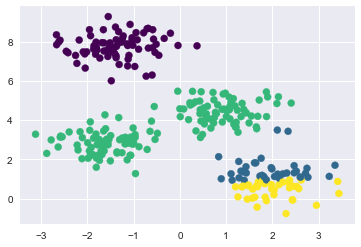

In [ ]:
## The below figure shows the sensitivity of initial random seed number

centers, labels = find_clusters(X, 4, rseed=0)
plt.scatter(X[:, 0], X[:, 1], c=labels,
            s=50, cmap='viridis');

## Pre-selected number of clusters

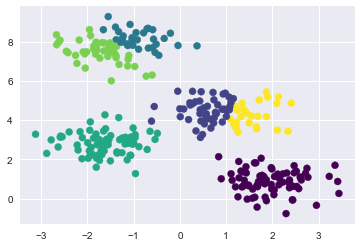

In [ ]:
labels = KMeans(6, random_state=0).fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels,
            s=50, cmap='viridis');

## only linear cluster boundaries
-  if data exhibit complicated geometric shape then KMeans-cluster performs poorly

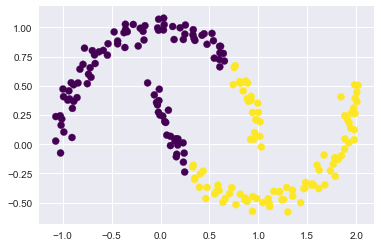

In [ ]:
from sklearn.datasets import make_moons
X, y = make_moons(200, noise=.05, random_state=0)

labels = KMeans(2, random_state=0).fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels,
            s=50, cmap='viridis');

### for non-linear boundaries: use Spectralclustering

C:\Anaconda3\lib\site-packages\sklearn\manifold\spectral_embedding_.py:234: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn("Graph is not fully connected, spectral embedding"


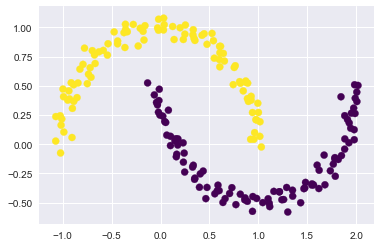

In [ ]:
from sklearn.cluster import SpectralClustering
model = SpectralClustering(n_clusters=2, affinity='nearest_neighbors',
                           assign_labels='kmeans')
labels = model.fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels,
            s=50, cmap='viridis');

## KMeans is very slow with larger data set
-  similar to curse of dimentionality

In [ ]:
## see ppt ClusterSparcityWithEmpirics.pptx